# In this example we finetune the G(Wa)NN model using a set of bilayer WSe_{2} Wannier Hamiltonians created using the stack and shift method (Physical Review B 93, 235153)

### Note that the Wannier Hamiltonians used for finetuning are created using the reduced orbital basis: W-d, Se-p

### This is not an issue, the finetuning procedure utilized subspace projection during training to create a new model head which utilizes only the new basis. 

### Built in helper functions set up the training and validation data. 

### Training data must be stored in a directory with seperate directories for each Wannier Hamiltonian. The directories should contain: the _hr.dat file (wannier90_hr.dat) and the .win file (wannier90.in)

### The wannier90.win file should include the flag fermi_energy = XXX, such that the energy levels are properly normalized. 

### The finetuning data is available at: 0.5281/zenodo.20542636

In [13]:
import os
from tailwater import (
    prepare_finetune_targets_from_directory,
    finetune_heads_multi,
)


# ----------------------------------------------------------------------
# Layout
# ----------------------------------------------------------------------
TRAIN_DIR = "../WSe2/train"            # one subdirectory per training material
VAL_DIR   = "../WSe2/val"              # one subdirectory per validation material
CACHE_DIR = "finetune_out/cache"        # per-material prepared targets get saved here
SAVE_DIR  = "finetune_out"              # final checkpoint lands here

ENERGY_RANGE = (-10.0, 6.0)              # eV — eigenvalues outside this window are masked
DEVICE       = "cpu"                     # use "cuda" if available

GENERATE_EMBEDDING = True               # call the API to generate missing embeddings
API_USER           = "tailwater_user"    # only used if GENERATE_EMBEDDING
API_PASSWORD       = "tailwater_password"    # only used if GENERATE_EMBEDDING

In [2]:
common = dict(
        out_dir            = CACHE_DIR,
        strict             = False,        # skip subdirectories missing any of the 3 files
        generate_embedding = GENERATE_EMBEDDING,
        user               = API_USER     if GENERATE_EMBEDDING else None,
        password           = API_PASSWORD if GENERATE_EMBEDDING else None,
    )

train_items = prepare_finetune_targets_from_directory(TRAIN_DIR, **common)
val_items   = prepare_finetune_targets_from_directory(VAL_DIR,   **common)


[generate_embedding] scanning 585 subdirectories for materials that need an embedding from the API ...
  [skip] s_-0.04_-0.04: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.08: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.12: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.17: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.21: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.29: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.33: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.38: embedding already present (embeddings.pt) — use force_regenerate=True to override
  [skip] s_-0.04_-0.42: embedding already present

In [14]:
final_ckpt = finetune_heads_multi(
        train_targets   = train_items,
        val_targets     = val_items or None,
        start_lr        = 1e-2,
        end_lr          = 1e-6,
        num_epochs      = 100,
        energy_range    = ENERGY_RANGE,
        decay_sigma     = 10.0,
        device          = DEVICE,
        save_path       = SAVE_DIR,
        val_every       = 5,
        loss_mode       = "subspace",
        # heads_checkpoint=None  -> use the packaged HeadsOnly_MACE.pth
        kgrid_n         = 4,
    )


[multi-finetune] train = 585 materials, val = 40 materials, loss_mode = 'subspace', window = [-10.000, +6.000] eV
[model] using packaged HeadsOnly checkpoint: /opt/anaconda3/envs/tailwater-test/lib/python3.11/site-packages/tailwater/HeadsOnly_MACE.pth
[model] HeadsOnly loaded — 61,520 trainable params, irreps_in = 64x0e+64x0o+32x1o+16x1e+12x2o+25x2e+18x3o+9x3e+4x4o+9x4e+4x5o+4x5e
Epoch   1/100  LR 9.998e-03  mean loss 3.019795e-01  mean eig 3.019187e-01  (585/585 materials)
Epoch   2/100  LR 9.990e-03  mean loss 3.692219e-01  mean eig 3.691318e-01  (585/585 materials)
Epoch   3/100  LR 9.978e-03  mean loss 3.167681e-01  mean eig 3.166745e-01  (585/585 materials)
Epoch   4/100  LR 9.961e-03  mean loss 2.451576e-01  mean eig 2.450710e-01  (585/585 materials)
Epoch   5/100  LR 9.938e-03  mean loss 2.516915e-01  mean eig 2.516172e-01  (585/585 materials)
       [val]   mean eig 2.668615e-01  *NEW BEST*
Epoch   6/100  LR 9.911e-03  mean loss 2.675019e-01  mean eig 2.674284e-01  (585/585 mat

In [15]:
import torch
import numpy as np
from tailwater import (                              # noqa: E402
    prepare_finetune_targets_from_directory,
    finetune_heads_multi,
    # for the post-training inference + band-structure demo at the bottom:
    load_heads_only_checkpoint,
    build_hr_model_fast,
    write_hr_output,
    tb_model,
    bulk_band_structure,
    align_to_vbm,
    parse_win_fermi_energy,
)
import tbmodels                     
import matplotlib.pyplot as plt


Building three-way band comparison for 's_-0.04_-0.25':
  - target     : the user's own hr-file (Fermi-shifted to E_F = 0)
  - pre-tune   : packaged HeadsOnly_MACE.pth, no fine-tune applied
  - post-tune  : HeadsFT_multi_best.pth from this run
  target Fermi shift: -+3.0718 eV (from wannier90.win)
  wrote post-finetune hr-model → ../WSe2/val/s_-0.04_-0.25/s_-0.04_-0.25_finetuned_hr.hdf5  (108 orbitals)
  wrote band-structure comparison → ../WSe2/val/s_-0.04_-0.25/s_-0.04_-0.25_bands_comparison.png


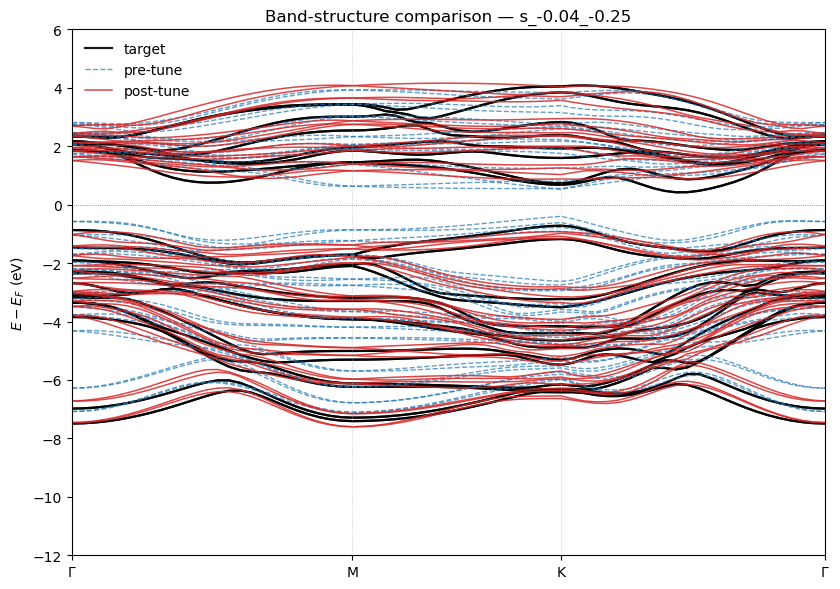

In [16]:
# ------------------------------------------------------------------
# 3)  Use the fine-tuned heads to build a model + plot bands for a
#     held-out validation material.
# ------------------------------------------------------------------
#     This is the inference workflow you'd run any time you want a
#     Hamiltonian out of the fine-tuned model: load the heads, hand
#     them the API embedding for the target structure, assemble the
#     resulting predictions into a tbmodels.Model via
#     build_hr_model_fast, and post-process as usual.
#
#     The embedding can come from one of two places:
#       (a) The .pt that prepare_finetune_targets_from_directory
#           already cached inside the validation subdirectory
#           (`{val_subdir}/embeddings.pt`) — this is the cheap path,
#           reuses the existing API call.
#       (b) A fresh API call with `tw_api_call(..., return_embeddings=True)`
#           for a structure you don't have an embedding for yet.
#     The example uses path (a) since the directory walker already
#     produced an embedding for every validation material.
# ------------------------------------------------------------------
#if not val_items:
    #print("No validation materials configured — skipping band plot.")
    #return
val_item   = val_items[0]
val_subdir = os.path.join(VAL_DIR, val_item["name"])
print(f"\nBuilding three-way band comparison for '{val_item['name']}':")
print(f"  - target     : the user's own hr-file (Fermi-shifted to E_F = 0)")
print(f"  - pre-tune   : packaged HeadsOnly_MACE.pth, no fine-tune applied")
print(f"  - post-tune  : HeadsFT_multi_best.pth from this run")

# ------------------------------------------------------------------
# 3a)  Load the API embedding once — both head checkpoints get it.
# ------------------------------------------------------------------
emb_pkg = torch.load(val_item["embed_path"], map_location=DEVICE,
                     weights_only=False)
gdata   = emb_pkg["data"].to(DEVICE)
LM      = np.asarray(emb_pkg["LM"], dtype=float)
atoms   = emb_pkg["atoms"]

# ------------------------------------------------------------------
# 3b)  Build the three tbmodels.Model objects to compare.
# ------------------------------------------------------------------
# (1) Target: the user's own hr-file.  Apply the .win's
#     `fermi_energy` to put E_F = 0, matching what the multi-finetune
#     loss saw during training.
win_path = os.path.join(val_subdir, "wannier90.win")
if not os.path.isfile(win_path):
    # fall back to whatever .win is in the directory (e.g. input.win)
    win_path = [os.path.join(val_subdir, n) for n in os.listdir(val_subdir)
                if n.lower().endswith(".win")][0]
hr_path = [os.path.join(val_subdir, n) for n in os.listdir(val_subdir)
           if n.lower().endswith(("_hr.dat", "_hr.hdf5", "_hr.h5"))
           and "finetuned" not in n][0]
if hr_path.lower().endswith((".hdf5", ".h5")):
    target_model = tbmodels.Model.from_hdf5_file(hr_path)
else:
    target_model = tbmodels.Model.from_wannier_files(
        hr_file = hr_path, win_file = win_path, pos_kind = "nearest_atom",
    )
ef = parse_win_fermi_energy(win_path)
if ef is not None:
    target_model = align_to_vbm(target_model, fermi_level=ef)
    print(f"  target Fermi shift: -{ef:+.4f} eV (from {os.path.basename(win_path)})")

# (2) Pre-finetune: the packaged HeadsOnly_MACE.pth (no training).
default_ckpt = os.path.join(
    os.path.dirname(tailwater.__file__), "HeadsOnly_MACE.pth",
)
heads_pre  = load_heads_only_checkpoint(default_ckpt, map_location=DEVICE).to(DEVICE).eval()
with torch.no_grad():
    edge_pre, onsite_pre = heads_pre(gdata)
pretune_model = build_hr_model_fast(edge_pre, onsite_pre, gdata, LM, atoms)

# (3) Post-finetune: the best-val (or final) HeadsFT_multi checkpoint.
best_ckpt = os.path.join(SAVE_DIR, "HeadsFT_multi_best.pth")
use_ckpt  = best_ckpt if os.path.isfile(best_ckpt) else final_ckpt
heads_post = load_heads_only_checkpoint(use_ckpt, map_location=DEVICE).to(DEVICE).eval()
with torch.no_grad():
    edge_post, onsite_post = heads_post(gdata)
posttune_model = build_hr_model_fast(edge_post, onsite_post, gdata, LM, atoms)

# Save the post-finetune model for downstream use.
pred_hr_path = os.path.join(val_subdir, f"{val_item['name']}_finetuned_hr.hdf5")
write_hr_output(posttune_model, pred_hr_path, fmt="hdf5")
print(f"  wrote post-finetune hr-model → {pred_hr_path}  "
      f"({posttune_model.size} orbitals)")

# ------------------------------------------------------------------
# 3c)  Compute bands for all three models on the same k-path and
#      overlay them on one figure for direct visual comparison.
# ------------------------------------------------------------------
# Generic Γ → M → K → Γ path; adjust for your crystal class.
band_path   = [[0.0, 0.0, 0.0],
               [0.5, 0.0, 0.0],
               [0.333, 0.333, 0.0],
               [0.0, 0.0, 0.0]]
band_labels = [r"$\Gamma$", "M", "K", r"$\Gamma$"]

# `threadpoolctl.threadpool_limits(1)` is the macOS-specific guard
# against the OpenMP runtime clash discussed at the top of this
# file. No-op on Linux.
try:
    from threadpoolctl import threadpool_limits
except ImportError:
    threadpool_limits = None
    print("  [warn] `threadpoolctl` is not installed; on macOS the band "
          "plot below may segfault. Install with `pip install "
          "threadpoolctl`.")

plot_ctx = threadpool_limits(limits=1) if threadpool_limits else _NullCtx()
with plot_ctx:
    # Get raw band data (k_dist + eigenvalues) for each model.
    models_styled = [
        (target_model,    "target",      "k",       "-",   1.6, 0.9),
        (pretune_model,   "pre-tune",    "tab:blue","--",  1.0, 0.7),
        (posttune_model,  "post-tune",   "tab:red", "-",   1.1, 0.85),
    ]
    results = []
    for m, _lbl, _c, _ls, _lw, _al in models_styled:
        results.append(bulk_band_structure(
            m, k_points=band_path, k_labels=band_labels,
            e_range=ENERGY_RANGE, spacing=0.02, verbose=False,
            return_raw=True,
        ))

    fig, ax = plt.subplots(figsize=(8.5, 6))
    for (_, label, color, ls, lw, alpha), res in zip(models_styled, results):
        kd   = res.k_dist
        eigs = res.eigenvalues                  # (N_path, num_bands)
        # First band carries the label; subsequent bands re-use color/style.
        ax.plot(kd, eigs[:, 0], color=color, ls=ls, lw=lw, alpha=alpha, label=label)
        for b in range(1, eigs.shape[1]):
            ax.plot(kd, eigs[:, b], color=color, ls=ls, lw=lw, alpha=alpha)
    ax.set_xticks(results[0].k_node)
    ax.set_xticklabels(results[0].k_labels)
    for x in results[0].k_node:
        ax.axvline(x, ls=":", color="0.7", lw=0.5)
    ax.axhline(0.0, ls=":", color="r",   lw=0.5)
    ax.set_xlim(results[0].k_dist[0], results[0].k_dist[-1])
    ax.set_ylim(-12,6)
    ax.set_ylabel(r"$E - E_F$ (eV)")
    ax.set_title(f"Band-structure comparison — {val_item['name']}")
    ax.legend(frameon=False, loc="best")
    fig.tight_layout()

    bands_png = os.path.join(val_subdir, f"{val_item['name']}_bands_comparison.png")
    fig.savefig(bands_png, dpi=180)
print(f"  wrote band-structure comparison → {bands_png}")


# ----------------------------------------------------------------------
# Alternative inference path: call the API afresh for a brand-new
# structure (one you have not yet generated an embedding for). Most of
# the time you don't need this — the directory walker already produced
# embeddings for every validation material — but it's the recipe to
# follow when the structure is brand new.
# ----------------------------------------------------------------------